In [3]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import seaborn as sns
from pathlib import Path
import plotly.graph_objects as go
pio.renderers.default = "notebook_connected"

In [4]:
path = r'C:\Data_analysis\Thesis\Data\02_Preprocessing\LF_data_droped.csv'
df = pd.read_csv(path,sep=',')
df.head(5)

,Time,BA_Soc,BU_TotActPwr_Academy,BA_TotActPwr_BESS_AC_Panel1,BA_TotActPwr_BESS_AC_Panel2,BU_TotActPwr_SDB_EL_Substation,BU_TotActPwr_Tech_Room,PV_WS_AirTemp,PV_WS_Radiation,PV_WS_RelHum
0,2025-10-15 00:00:00,83.4,4.148,1.630,0.419,NaN,3.614,129.0,-4.6,83.5
1,2025-10-15 00:05:00,83.4,3.631,1.632,0.421,NaN,3.608,129.0,-4.3,83.8
2,2025-10-15 00:10:00,83.3,3.572,1.633,0.420,NaN,3.646,127.0,-4.7,84.1
3,2025-10-15 00:15:00,83.2,3.663,1.636,0.418,NaN,3.601,127.0,-4.5,84.3
4,2025-10-15 00:20:00,83.1,3.610,1.634,0.426,NaN,3.646,126.0,-4.5,85.0


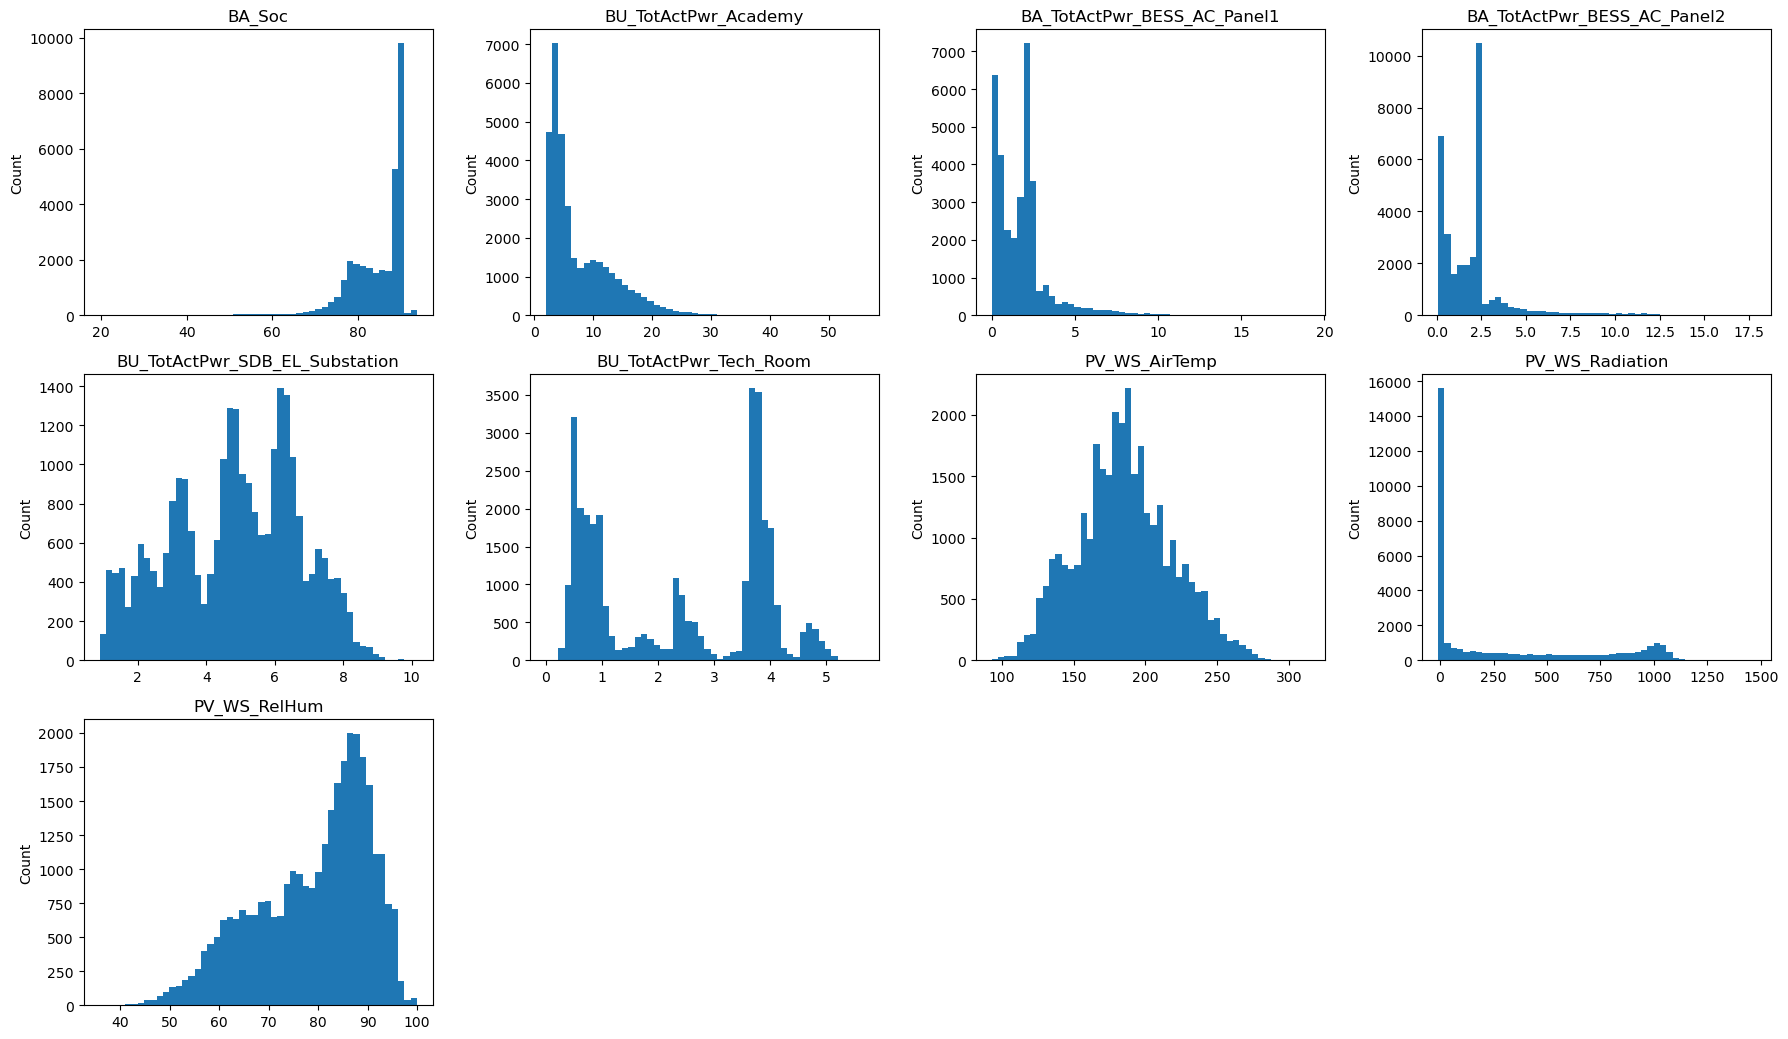

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if not df[c].isna().all()]
n = len(num_cols)
if n == 0:
    print("No numeric columns available")
else:
    ncols = 4 
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(num_cols):
        x = df[col].dropna()
        axes[i].hist(x, bins=50)
        axes[i].set_title(col)
        axes[i].set_ylabel("Count")

    # Turn off empty subplots
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [6]:
print(df.shape)
print(df.columns)

(33696, 10)
Index(['Time', 'BA_Soc', 'BU_TotActPwr_Academy', 'BA_TotActPwr_BESS_AC_Panel1',
       'BA_TotActPwr_BESS_AC_Panel2', 'BU_TotActPwr_SDB_EL_Substation',
       'BU_TotActPwr_Tech_Room', 'PV_WS_AirTemp', 'PV_WS_Radiation',
       'PV_WS_RelHum'],
      dtype='str')


In [ ]:
df['Time'] = pd.to_datetime(df['Time'], errors = 'coerce')
df.set_index('Time', inplace=True)

In [8]:
print(df.shape)
print(df.columns)

(33696, 9)
Index(['BA_Soc', 'BU_TotActPwr_Academy', 'BA_TotActPwr_BESS_AC_Panel1',
       'BA_TotActPwr_BESS_AC_Panel2', 'BU_TotActPwr_SDB_EL_Substation',
       'BU_TotActPwr_Tech_Room', 'PV_WS_AirTemp', 'PV_WS_Radiation',
       'PV_WS_RelHum'],
      dtype='str')


In [ ]:
def impute_loads_by_gap_categories_safe(
    df: pd.DataFrame,
    load_cols: list[str],
    *,
    freq_minutes: int = 5,
    short_gap_hours: float = 2.0,     # Cat-1
    medium_gap_hours: float = 24.0,   # Cat-2 up to 24h
    min_history: int = 5,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    out = df.copy().sort_index()

    if not isinstance(out.index, pd.DatetimeIndex):
        raise TypeError("df must have a DatetimeIndex.")
    if out.index.has_duplicates:
        raise ValueError("DatetimeIndex has duplicates. Resolve duplicates before imputing.")

    # numeric
    out[load_cols] = out[load_cols].apply(pd.to_numeric, errors="coerce")

    # thresholds in samples
    samples_per_hour = int(round(60 / freq_minutes))  # 5-min => 12
    short_thr = int(round(short_gap_hours * samples_per_hour))     # 2h => 24
    medium_thr = int(round(medium_gap_hours * samples_per_hour))   # 24h => 288

    # temp keys for profile
    out["_dow"] = out.index.dayofweek
    out["_mod"] = out.index.hour * 60 + out.index.minute

    report_rows = []

    for col in load_cols:
        s = out[col]

        # ----- Cat-1: interpolate only short runs -----
        is_na = s.isna()
        run_id = is_na.ne(is_na.shift()).cumsum()
        run_len = is_na.groupby(run_id).transform("sum")

        long_mask = is_na & (run_len > short_thr)

        s_interp = s.interpolate(method="time", limit=short_thr, limit_direction="forward")
        s_interp.loc[long_mask] = np.nan
        out.loc[:, col] = s_interp  # single-step assignment

        # recompute after cat-1
        s = out[col]
        is_na = s.isna()
        run_id = is_na.ne(is_na.shift()).cumsum()
        run_len = is_na.groupby(run_id).transform("sum")

        nan_run_lengths = run_len[is_na].groupby(run_id[is_na]).first()

        report_rows.append({
            "column": col,
            "NaNs_after_cat1": int(is_na.sum()),
            "NaN_runs_after_cat1": int(nan_run_lengths.shape[0]),
            "min_run": int(nan_run_lengths.min()) if nan_run_lengths.shape[0] else 0,
            "max_run": int(nan_run_lengths.max()) if nan_run_lengths.shape[0] else 0,
            "runs_cat2_(2h_to_24h)": int(((nan_run_lengths > short_thr) & (nan_run_lengths <= medium_thr)).sum()) if nan_run_lengths.shape[0] else 0,
            "runs_cat3_(>24h)": int((nan_run_lengths > medium_thr).sum()) if nan_run_lengths.shape[0] else 0,
        })

        # ----- Cat-2/Cat-3: fill remaining NaNs, past-only -----
        nan_idx = out.index[out[col].isna()]  # timestamps (safe to use in .loc)

        for ts in nan_idx:
            L = int(run_len.loc[ts])  # run length at this timestamp
            dow = int(out.loc[ts, "_dow"])
            mod = int(out.loc[ts, "_mod"])

            past = out.loc[:ts].iloc[:-1]  # strictly past rows only (no leakage)

            # Cat-2: (2h, 24h]
            if (L > short_thr) and (L <= medium_thr):
                cands = past.loc[(past["_dow"] == dow) & (past["_mod"] == mod), col].dropna()
                if len(cands) >= min_history:
                    out.loc[ts, col] = float(cands.mean())
                    continue

            # Cat-3: >24h (robust fallback)
            cands2 = past.loc[past["_mod"] == mod, col].dropna()
            if len(cands2) >= min_history:
                out.loc[ts, col] = float(cands2.median())
                continue

            # Final fallback: past global median
            cands3 = past[col].dropna()
            if len(cands3) > 0:
                out.loc[ts, col] = float(cands3.median())

    out = out.drop(columns=["_dow", "_mod"])
    report = pd.DataFrame(report_rows)
    return out, report

In [ ]:
load_cols = ['BA_Soc', 'BU_TotActPwr_Academy', 'BA_TotActPwr_BESS_AC_Panel1',
            'BA_TotActPwr_BESS_AC_Panel2', 'BU_TotActPwr_SDB_EL_Substation',
            'BU_TotActPwr_Tech_Room', 'PV_WS_AirTemp', 'PV_WS_Radiation',
            'PV_WS_RelHum']

df_imputed, impute_report = impute_loads_by_gap_categories_safe(df, load_cols)

print(impute_report)
print(df_imputed[load_cols].isna().sum())

### Category 1: Short gaps (≤ 2 hours)
- Missing run length is **2 hours or less**
- Imputation method: **time-based interpolation**
- Reason:
  - For short gaps, the signal usually changes smoothly
  - Interpolation preserves local continuity and trend

### Category 2: Medium gaps (> 2 hours and ≤ 24 hours)
- Missing run length is **more than 2 hours but not more than 24 hours**
- Imputation method: **historical mean**
- Based on:
  - **same day of week**
  - **same time of day**
  - **past data only**
- Reason:
  - Medium gaps are too long for interpolation can lead wronge data imputation and loosing pattern
  - Using historical behavior at the same weekly time pattern is more practicle

### Category 3: Long gaps (> 24 hours)
- Missing run length is **longer than 24 hours**
- Imputation method: **historical median**
- Based on:
  - **same time of day**
  - **past data only**
- Reason:
  - Very long gaps are more uncertain
  - Median is more robust than mean and less sensitive to extreme values



- **future data is never used**, so forecasting integrity is preserved **To avoid data leakage**


### Missing check

In [ ]:
#### Missing Value check

# missing values summary by ech features (count and percent)
missing_count = df_imputed.isnull().sum()
missing_pct = (df_imputed.isnull().mean() * 100).round(2)
missing_summary = pd.concat([missing_count, missing_pct], axis=1)
missing_summary.columns = ['missing_count', 'missing_pct']
missing_summary = missing_summary.sort_values('missing_count', ascending=False)

if missing_summary['missing_count'].sum() == 0:
    print("No missing values found.")
else:
    print(missing_summary[missing_summary['missing_count'] > 0])

    # number of rows with any missing value and a sample of such rows
    n_rows_with_missing = df_imputed.isnull().any(axis=1).sum()
    print(f"\nRows with any missing values: {n_rows_with_missing}")


### Plot before / after impute

In [ ]:
# import plotly.graph_objects as go

# load_cols = ['PV_WS_AirTemp', 'PV_WS_Radiation','PV_WS_RelHum','BU_TotActPwr_SDB_EL_Substation','BA_Soc']  # change

# for col in load_cols:
#     s_raw = df[col]
#     s_imp = df_imputed[col]

#     imputed_mask = s_raw.isna() & s_imp.notna()

#     fig = go.Figure()

#     # Original (gaps show naturally where NaN)
#     fig.add_trace(go.Scatter(
#         x=s_raw.index, y=s_raw.values,
#         mode="lines",
#         name="Original (NaNs=gaps)",
#         opacity=0.6
#     ))

#     # Imputed series
#     fig.add_trace(go.Scatter(
#         x=s_imp.index, y=s_imp.values,
#         mode="lines",
#         name="After imputation"
#     ))

#     # Highlight imputed points
#     fig.add_trace(go.Scatter(
#         x=s_imp.index[imputed_mask],
#         y=s_imp.loc[imputed_mask].values,
#         mode="markers",
#         name="Imputed points",
#         marker=dict(size=5)
#     ))

#     fig.update_layout(
#         title=f"{col}: Original vs Imputed (entire timeframe)",
#         xaxis_title="Time",
#         yaxis_title=col,
#         hovermode="x unified",
#         template="plotly_white",
#     )

#     fig.show()

### Save imputed value to main df

In [ ]:
df.loc[:, load_cols] = df_imputed.loc[:, load_cols]

## Plotting function

In [ ]:
# def plot_feature(df, cols=None, start=None, end=None, connectgaps=False):
#     d = df.copy()

#     # ensure datetime index
#     d.index = pd.to_datetime(d.index, errors="coerce")
#     d = d[~d.index.isna()].sort_index()

#     # time filter
#     if start is not None or end is not None:
#         d = d.loc[start:end]

#     # choose columns
#     if cols is None:
#         cols = d.columns.tolist()

#     # numeric convert (important if some columns are strings)
#     d[cols] = d[cols].apply(pd.to_numeric, errors="coerce")

#     # plot multiple columns
#     fig = px.line(d, x=d.index, y=cols,)
#     fig.update_traces(connectgaps=connectgaps)
#     fig.show()


In [ ]:
# plot_feature(df,"PV_WS_Radiation")
# plot_feature(df,"PV_WS_AirTemp")
# plot_feature(df,"PV_WS_RelHum")
# plot_feature(df,'BA_Soc')

## calendar features

In [ ]:
#### Missing Value check

# missing values summary by ech features (count and percent)
missing_count = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_summary = pd.concat([missing_count, missing_pct], axis=1)
missing_summary.columns = ['missing_count', 'missing_pct']
missing_summary = missing_summary.sort_values('missing_count', ascending=False)

if missing_summary['missing_count'].sum() == 0:
    print("No missing values found.")
else:
    print(missing_summary[missing_summary['missing_count'] > 0])

    # number of rows with any missing value and a sample of such rows
    n_rows_with_missing = df.isnull().any(axis=1).sum()
    print(f"\nRows with any missing values: {n_rows_with_missing}")


In [ ]:
df = df.sort_index()
idx = df.index

# Basic calendar features
df["dayofweek"] = idx.dayofweek                 # Monday=0, Sunday=6
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
df["hour"] = idx.hour
df["month"] = idx.month
df["dayofmonth"] = idx.day

# Time of day
df["minute_of_day"] = idx.hour * 60 + idx.minute

# Cyclical encoding for time of day
df["sin_tod"] = np.sin(2 * np.pi * df["minute_of_day"] / 1440)
df["cos_tod"] = np.cos(2 * np.pi * df["minute_of_day"] / 1440)

# Cyclical encoding for day of week
df["sin_dow"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["cos_dow"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

# Optional business-hours flag
df["is_business_hours"] = (
    (idx.hour >= 8) & (idx.hour < 18) & (df["dayofweek"] < 5)
).astype(int)
df["is_midday_peak_window"] = ((idx.hour >= 11) & (idx.hour < 14)).astype(int)
df["is_midday_weekday_peak"] = (
    (idx.hour >= 11) & (idx.hour < 14) & (idx.dayofweek < 5)
).astype(int)

df["slot_5min"] = idx.hour * 12 + idx.minute // 5

In [ ]:
one_day = df.loc[df.index.date == df.index.date[0], ["sin_tod", "cos_tod"]]

plt.figure()
plt.plot(one_day.index, one_day["sin_tod"], label="sin_tod")
plt.plot(one_day.index, one_day["cos_tod"], label="cos_tod")
plt.title("Time-of-day cyclic features (1 day)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
target = "BU_TotActPwr_Academy"  # <-- change to your load column name

week = df.iloc[: 7 * 24 * 12].copy()  # 7 days * 24h * 12 samples/hour (5-min)

plt.figure()
plt.plot(week.index, week[target], label=target)

# highlight weekend points
weekend = week[week["is_weekend"] == 1]
plt.scatter(weekend.index, weekend[target], s=8, label="weekend")

plt.title("Load over 1 week (weekends highlighted)")
plt.xlabel("Time")
plt.ylabel(target)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
target = "BU_TotActPwr_Academy"  # <-- change to your load column name

tmp = df.copy()
tmp["hour"] = tmp.index.hour
tmp["dow"] = tmp.index.dayofweek

pivot = tmp.pivot_table(values=target, index="dow", columns="hour", aggfunc="mean")

plt.figure()
plt.imshow(pivot.values, aspect="auto")
plt.title("Average load by day-of-week (rows) and hour (cols)")
plt.xlabel("Hour of day")
plt.ylabel("Day of week (Mon=0)")
plt.colorbar(label=f"Mean {target}")
plt.xticks(range(0, 24, 2))
plt.yticks(range(0, 7))
plt.tight_layout()
plt.show()


In [ ]:
print(df.shape)
print(df.columns)

### lagg features 

In [ ]:
target_col = ['BU_TotActPwr_Academy', 'BA_TotActPwr_BESS_AC_Panel1',
       'BA_TotActPwr_BESS_AC_Panel2',
       'BU_TotActPwr_Tech_Room']
print(df[target_col].isna().sum())

In [ ]:
#### Missing Value check

# missing values summary by ech features (count and percent)
missing_count = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_summary = pd.concat([missing_count, missing_pct], axis=1)
missing_summary.columns = ['missing_count', 'missing_pct']
missing_summary = missing_summary.sort_values('missing_count', ascending=False)

if missing_summary['missing_count'].sum() == 0:
    print("No missing values found.")
else:
    print(missing_summary[missing_summary['missing_count'] > 0])

    # number of rows with any missing value and a sample of such rows
    n_rows_with_missing = df.isnull().any(axis=1).sum()
    print(f"\nRows with any missing values: {n_rows_with_missing}")


In [ ]:
df = df.sort_index()
load_cols = ['BU_TotActPwr_Academy', 'BA_TotActPwr_BESS_AC_Panel1',
       'BA_TotActPwr_BESS_AC_Panel2',
       'BU_TotActPwr_Tech_Room']   #'BU_TotActPwr_SDB_EL_Substation' is excluded for now

lags = [1, 2, 3, 6, 12, 24, 36, 48, 72, 144, 288, 576]

# create lag features
for col in load_cols:
    for lag in lags:
        df[f"{col}_lag_{lag}"] = df[col].shift(lag)



In [ ]:
print(df.shape)
print(df.columns)

### rolling mean and rolling std

In [ ]:
feature_dict = {}
rolling_windows = [6, 12, 36, 288]

for col in load_cols:
    shifted_1 = df[col].shift(1)
    shifted_12 = df[col].shift(12)
    shifted_288 = df[col].shift(288)

    for win in rolling_windows:
        feature_dict[f"{col}_roll_mean_{win}"] = shifted_1.rolling(win).mean()

    feature_dict[f"{col}_roll_std_12"] = shifted_1.rolling(12).std()
    feature_dict[f"{col}_roll_std_36"] = shifted_1.rolling(36).std()
    feature_dict[f"{col}_roll_min_12"] = shifted_1.rolling(12).min()
    feature_dict[f"{col}_roll_max_12"] = shifted_1.rolling(12).max()
    feature_dict[f"{col}_trend_1h"] = shifted_1 - shifted_12
    feature_dict[f"{col}_trend_24h"] = shifted_1 - shifted_288

df = pd.concat([df, pd.DataFrame(feature_dict, index=df.index)], axis=1)

In [ ]:
print(df.shape)
print(df.columns)

### build load wise df and drop starting NaN

In [ ]:
def build_target_df(
    df: pd.DataFrame,
    target_col: str,
    support_cols: list[str],
    *,
    add_calendar: bool = True
) -> pd.DataFrame:
    
    out = df.copy()

    calendar_cols = []
    if add_calendar:
        calendar_cols = [
            "dayofweek", "is_weekend", "hour", "month", "dayofmonth",
            "minute_of_day", "sin_tod", "cos_tod",
            "sin_dow", "cos_dow", "is_midday_peak_window", "is_business_hours","is_midday_weekday_peak","slot_5min"
        ]

    lag_cols = [c for c in out.columns if c.startswith(f"{target_col}_lag_")]
    roll_cols = [c for c in out.columns if c.startswith(f"{target_col}_roll_")] 
    trend_cols = [c for c in out.columns if c.startswith(f"{target_col}_trend_")]
    selected_cols = [target_col] + support_cols + calendar_cols + lag_cols + roll_cols  + trend_cols

    # keep only columns that actually exist
    selected_cols = [c for c in selected_cols if c in out.columns]

    out = out[selected_cols].copy()
    return out

In [ ]:
def clean_target_df(
    df_target: pd.DataFrame,
    target_col: str,
    *,
    drop_startup: bool = True,
    startup_rows: int = 576
) -> pd.DataFrame:

    out = df_target.copy()

    if drop_startup:
        out = out.iloc[startup_rows:].copy()

    # Drop rows where target is NaN
    #out = out[out[target_col].notna()].copy()

    return out

In [ ]:
support_cols = ['BA_Soc', 'PV_WS_AirTemp','PV_WS_Radiation', 'PV_WS_RelHum'] 

In [ ]:
df_BU_TotActPwr_Academy_imp = build_target_df(df, target_col="BU_TotActPwr_Academy", support_cols=support_cols)
df_BU_TotActPwr_Tech_Room_imp = build_target_df(df, target_col="BU_TotActPwr_Tech_Room", support_cols=support_cols)
df_BA_TotActPwr_BESS_AC_Panel1_imp = build_target_df(df, target_col="BA_TotActPwr_BESS_AC_Panel1", support_cols=support_cols)
df_BA_TotActPwr_BESS_AC_Panel2_imp = build_target_df(df, target_col="BA_TotActPwr_BESS_AC_Panel2", support_cols=support_cols)

In [ ]:
df_BU_TotActPwr_Academy_imp = clean_target_df(df_BU_TotActPwr_Academy_imp, target_col="BU_TotActPwr_Academy", drop_startup=True, startup_rows=576)
df_BU_TotActPwr_Tech_Room_imp = clean_target_df(df_BU_TotActPwr_Tech_Room_imp, target_col="BU_TotActPwr_Tech_Room", drop_startup=True, startup_rows=576)
df_BA_TotActPwr_BESS_AC_Panel1_imp = clean_target_df(df_BA_TotActPwr_BESS_AC_Panel1_imp, target_col="BA_TotActPwr_BESS_AC_Panel1", drop_startup=True, startup_rows=576)
df_BA_TotActPwr_BESS_AC_Panel2_imp = clean_target_df(df_BA_TotActPwr_BESS_AC_Panel2_imp, target_col="BA_TotActPwr_BESS_AC_Panel2", drop_startup=True, startup_rows=576)

In [ ]:
#### Missing Value check df_BU_TotActPwr_Academy_imp

# missing values summary by ech features (count and percent)
missing_count = df_BU_TotActPwr_Academy_imp.isnull().sum()
missing_pct = (df_BU_TotActPwr_Academy_imp.isnull().mean() * 100).round(2)
missing_summary = pd.concat([missing_count, missing_pct], axis=1)
missing_summary.columns = ['missing_count', 'missing_pct']
missing_summary = missing_summary.sort_values('missing_count', ascending=False)

if missing_summary['missing_count'].sum() == 0:
    print("No missing values found.")
else:
    print(missing_summary[missing_summary['missing_count'] > 0])

    # number of rows with any missing value and a sample of such rows
    n_rows_with_missing = df_BU_TotActPwr_Academy_imp.isnull().any(axis=1).sum()
    print(f"\nRows with any missing values: {n_rows_with_missing}")


In [ ]:
#### Missing Value check df_BU_TotActPwr_Tech_Room_imp

# missing values summary by ech features (count and percent)
missing_count = df_BU_TotActPwr_Tech_Room_imp.isnull().sum()
missing_pct = (df_BU_TotActPwr_Tech_Room_imp.isnull().mean() * 100).round(2)
missing_summary = pd.concat([missing_count, missing_pct], axis=1)
missing_summary.columns = ['missing_count', 'missing_pct']
missing_summary = missing_summary.sort_values('missing_count', ascending=False)

if missing_summary['missing_count'].sum() == 0:
    print("No missing values found.")
else:
    print(missing_summary[missing_summary['missing_count'] > 0])

    # number of rows with any missing value and a sample of such rows
    n_rows_with_missing = df_BU_TotActPwr_Tech_Room_imp.isnull().any(axis=1).sum()
    print(f"\nRows with any missing values: {n_rows_with_missing}")


In [ ]:
#### Missing Value check df_BA_TotActPwr_BESS_AC_Panel1_imp

# missing values summary by ech features (count and percent)
missing_count = df_BA_TotActPwr_BESS_AC_Panel1_imp.isnull().sum()
missing_pct = (df_BA_TotActPwr_BESS_AC_Panel1_imp.isnull().mean() * 100).round(2)
missing_summary = pd.concat([missing_count, missing_pct], axis=1)
missing_summary.columns = ['missing_count', 'missing_pct']
missing_summary = missing_summary.sort_values('missing_count', ascending=False)

if missing_summary['missing_count'].sum() == 0:
    print("No missing values found.")
else:
    print(missing_summary[missing_summary['missing_count'] > 0])

    # number of rows with any missing value and a sample of such rows
    n_rows_with_missing = df_BA_TotActPwr_BESS_AC_Panel1_imp.isnull().any(axis=1).sum()
    print(f"\nRows with any missing values: {n_rows_with_missing}")


In [ ]:
#### Missing Value check df_BA_TotActPwr_BESS_AC_Panel2_imp

# missing values summary by ech features (count and percent)
missing_count = df_BA_TotActPwr_BESS_AC_Panel2_imp.isnull().sum()
missing_pct = (df_BA_TotActPwr_BESS_AC_Panel2_imp.isnull().mean() * 100).round(2)
missing_summary = pd.concat([missing_count, missing_pct], axis=1)
missing_summary.columns = ['missing_count', 'missing_pct']
missing_summary = missing_summary.sort_values('missing_count', ascending=False)

if missing_summary['missing_count'].sum() == 0:
    print("No missing values found.")
else:
    print(missing_summary[missing_summary['missing_count'] > 0])

    # number of rows with any missing value and a sample of such rows
    n_rows_with_missing = df_BA_TotActPwr_BESS_AC_Panel2_imp.isnull().any(axis=1).sum()
    print(f"\nRows with any missing values: {n_rows_with_missing}")


### Save to Parquet file

In [ ]:
save_dir = Path(r"C:\Data_analysis\Thesis\Data\03_Training\Imputed_data")
save_dir.mkdir(parents=True, exist_ok=True)

file1 = save_dir / "df_BU_TotActPwr_Academy_imp.parquet"
file2 = save_dir / "df_BU_TotActPwr_Tech_Room_imp.parquet"
file3 = save_dir / "df_BA_TotActPwr_BESS_AC_Panel1_imp.parquet"
file4 = save_dir / "df_BA_TotActPwr_BESS_AC_Panel2_imp.parquet"

df_BU_TotActPwr_Academy_imp.to_parquet(file1, engine="pyarrow")
df_BU_TotActPwr_Tech_Room_imp.to_parquet(file2, engine="pyarrow")
df_BA_TotActPwr_BESS_AC_Panel1_imp.to_parquet(file3, engine="pyarrow")
df_BA_TotActPwr_BESS_AC_Panel2_imp.to_parquet(file4, engine="pyarrow")

print(file1)
print(file2)
print(file3)
print(file4)
print(file1.exists())
print(file2.exists())
print(file3.exists())
print(file4.exists())

### Pearson correlation of lagged and supporting features

In [ ]:
load_cols = ['BU_TotActPwr_Academy', 'BA_TotActPwr_BESS_AC_Panel1',
       'BA_TotActPwr_BESS_AC_Panel2',
       'BU_TotActPwr_Tech_Room'] 

for target in load_cols:
    lag_cols = [c for c in df.columns if c.startswith(f"{target}_lag")]

    corr = df[[target] + lag_cols].corr()[target].drop(target)

    print(f"\nCorrelation for {target}")
    print(corr.sort_values(ascending=False))

In [ ]:
load_cols = ['BU_TotActPwr_Academy', 'BA_TotActPwr_BESS_AC_Panel1',
       'BA_TotActPwr_BESS_AC_Panel2',
       'BU_TotActPwr_Tech_Room'] 

fig, axes = plt.subplots(len(load_cols), 1, figsize=(10, 12), sharex=False)

for i, target in enumerate(load_cols):
    
    lag_cols = [c for c in df.columns if c.startswith(f"{target}_lag")]
    
    corr = df[[target] + lag_cols].corr()[target].drop(target)
    
    corr.sort_values().plot(kind="barh", ax=axes[i])
    
    axes[i].set_title(f"Lag Correlation for {target}")
    axes[i].set_xlabel("Correlation")

plt.tight_layout()
plt.show()

In [ ]:

for target in load_cols:
    
    lag_cols = [c for c in df.columns if c.startswith(f"{target}_lag")]
    
    corr = df[[target] + lag_cols].corr()

    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, cmap="coolwarm")
    plt.title(f"Correlation Heatmap for {target}")
    plt.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

load_cols = ['BU_TotActPwr_Academy', 'BA_TotActPwr_BESS_AC_Panel1',
       'BA_TotActPwr_BESS_AC_Panel2',
       'BU_TotActPwr_Tech_Room']

fig, axes = plt.subplots(len(load_cols), 1, figsize=(10, 12))

for i, col in enumerate(load_cols):
    
    plot_acf(df[col], lags=288, ax=axes[i])
    axes[i].set_title(f"Autocorrelation Function (ACF) - {col}")

plt.tight_layout()
plt.show()

In [ ]:
load_cols = ['BU_TotActPwr_Academy', 'BA_TotActPwr_BESS_AC_Panel1',
       'BA_TotActPwr_BESS_AC_Panel2',
       'BU_TotActPwr_Tech_Room']

support_cols = [
    "PV_WS_Radiation",
    "PV_WS_AirTemp",
    "PV_WS_RelHum",
    "BA_Soc"
]
for load in load_cols:

    corr = df[support_cols + [load]].corr()[load].drop(load)

    print(f"\nCorrelation with {load}")
    print(corr.sort_values(ascending=False))




cols = load_cols + support_cols

corr = df[cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation between Load and Supporting Features")
plt.show()

In [ ]:
corr_matrix = df[load_cols + support_cols].corr().loc[load_cols, support_cols]

plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Load vs Supporting Feature Correlation")
plt.show()

In [ ]:
calendar_cols = [
    "sin_tod",
    "cos_tod",
    "dayofweek",
    "is_weekend"
]

cols = load_cols + calendar_cols

corr = df[cols].corr()

print(corr.loc[load_cols, calendar_cols])

In [ ]:

corr = df[load_cols + calendar_cols].corr().loc[load_cols, calendar_cols]

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Load vs Calendar Feature Correlation")
plt.show()

In [ ]:
df.head(5)

# Next Steps: Machine Learning Model Development


## 1. Time-Series Data Splitting
The dataset will be split chronologically into:
- **Training set**
- **Validation set**
- **Test set**

This avoids data leakage and ensures the model is evaluated on future unseen data.



## 2. Regression-Based Models
Since load forecasting is a continuous prediction task, regression models will be used, such as:
- Random Forest
- XGBoost


## 3. Multiple Load Forecasting
Separate models will be trained for different load signals while using a consistent training pipeline.



## 4. Model Evaluation
Performance will be evaluated using:
- **MAE**
- **RMSE**
- **MAPE**

## **without imputation and with imputation and comparision of XGboost**